Title: capacity_data_offshore.ipynb

Purpose: Transform the xml capacity data into some gridded format

Author: Onno Nennecke on 10.02.2025 Modified: 18.06.2025

Input data: 

- Wind energy units from the MaStR
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml

Output data:

- wind_offshore_ic.nc and wind_offnshore_height_weighted.nc
    - This file lies here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data

In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Seelage': int(einheit.find('Seelage').text) if einheit.find('Seelage') is not None else np.nan,
            # 'ClusterNordsee': int(einheit.find('ClusterNordsee').text) if einheit.find('ClusterNordsee') is not None else np.nan,
            # 'ClusterOstsee': int(einheit.find('ClusterOstsee').text) if einheit.find('ClusterOstsee') is not None else np.nan,
            'Wassertiefe': float(einheit.find('Wassertiefe').text) if einheit.find('Wassertiefe') is not None else np.nan,
            'Kuestenentfernung': float(einheit.find('Kuestenentfernung').text) if einheit.find('Kuestenentfernung') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
# print(df)

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop on-shore units
df_2 = df_1[df_1['Lage'] == 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)

6689


In [5]:
# Some data inspection because of nan values

# df_2['Kuestenentfernung'].isna().sum()

# df_2['Wassertiefe'].isna().sum()

# df_2[df_2['Kuestenentfernung'].isna()]

# All data entries without Wassertiefe and Kuestenentfernung are all in one windpark (not important for further analysis)

In [5]:
# Transform to shapefile
gdf = gpd.GeoDataFrame(df_2, geometry=gpd.points_from_xy(df_2['Laengengrad'], df_2['Breitengrad']))
gdf.crs = 'EPSG:4326'

In [7]:
# Save offshore windpark data as shapefile
# gdf.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/offshore_windparks.shp')

In [6]:
# Create a grid
grid = grid_func.create_ref_grid('wind_off_cap')
# grid

In [9]:
# Change coordinates to grid coordinates - Old version --> Wrong
# gdf["lat_idx"] = np.searchsorted(grid['lat'], gdf["Breitengrad"]) # Zeilenindex für Latitude
# gdf["lon_idx"] = np.searchsorted(grid['lon'], gdf["Laengengrad"]) # Spaltenindex für Longitude

# gdf

In [7]:
# Extract lat/lon center coordinates from the xarray grid (assumed 1D)
lat_vals = grid['lat'].values  # shape (N,)
lon_vals = grid['lon'].values  # shape (M,)

# Create 2D meshgrid of all (lat, lon) combinations
lat_mesh, lon_mesh = np.meshgrid(lat_vals, lon_vals, indexing='ij')  # shape (N, M)

# Flatten meshgrid into a (N*M, 2) array of grid point coordinates
grid_points = np.column_stack((lat_mesh.ravel(), lon_mesh.ravel()))

# Build KDTree for fast nearest neighbor search
tree = cKDTree(grid_points)

# Extract coordinates from GeoDataFrame into a (n_points, 2) array
data_points = np.column_stack((gdf["Breitengrad"].values, gdf["Laengengrad"].values))

# Query KDTree to find nearest grid point for each data point
distances, flat_indices = tree.query(data_points)  # returns (distance, index)

# Convert flat index to 2D grid indices (lat_idx, lon_idx)
gdf["lat_idx"], gdf["lon_idx"] = np.unravel_index(flat_indices, lat_mesh.shape)  # shape (n_points,)

gdf

,EinheitMastrNummer,Bruttoleistung,Nettonennleistung,NameWindpark,Nabenhoehe,Rotordurchmesser,Seelage,Wassertiefe,Kuestenentfernung,Laengengrad,Breitengrad,geometry,lat_idx,lon_idx
223,SEE991181426935,6300.0,6300.0,OWP Veja Mate,103.28,154.0,640.0,39.8,63.923,5.828958,54.341550,POINT (5.82896 54.34155),7,0
303,SEE948492783349,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,29.8,50.570,7.174499,55.067578,POINT (7.1745 55.06758),8,1
338,SEE996261343003,3780.0,3780.0,OWP DanTysk,88.00,120.0,640.0,28.7,50.650,7.175124,55.075620,POINT (7.17512 55.07562),8,1
623,SEE990582178207,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.6,30.740,13.083867,54.949617,POINT (13.08387 54.94962),8,7
627,SEE969452881615,3780.0,3780.0,Baltic 2,78.25,120.0,639.0,42.0,31.230,13.092806,54.957388,POINT (13.09281 54.95739),8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34289,SEE982413596991,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,30.2,22.200,7.096548,54.030592,POINT (7.09655 54.03059),7,1
34290,SEE905373051485,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.9,22.000,7.085100,54.023670,POINT (7.0851 54.02367),7,1
34291,SEE942700031529,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.5,21.700,7.073857,54.016865,POINT (7.07386 54.01686),7,1
34292,SEE980736061066,11550.0,11550.0,Gode Wind 3,126.50,200.0,640.0,29.0,21.500,7.063277,54.010465,POINT (7.06328 54.01046),7,1


In [11]:
# print(gdf['Laengengrad'].min())
# print(gdf['Laengengrad'].max())

# print(gdf['Breitengrad'].min())
# print(gdf['Breitengrad'].max())

# print(gdf['lat_idx'].min())
# print(gdf['lat_idx'].max())

# print(gdf['lon_idx'].min())
# print(gdf['lon_idx'].max())

In [8]:
grid_sums_old = gdf.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [9]:
grid_sums = gdf.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [10]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid)

In [11]:
# show overall sum
gdf['Bruttoleistung'].sum()

np.float64(9215093.0)

In [12]:
grid = grid.assign_attrs(gridtype='lonlat', crs='EPSG:4326')
grid

<xarray.DataArray 'wind_off_cap' (lat: 9, lon: 10)> Size: 720B
array([[     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [     nan,      nan,      nan,      nan,      nan,      nan,
             nan,      nan,      nan,      nan],
       [2653590., 2237778.,  996300.,      nan,      nan,      nan,
             nan,      nan,    6300.,      nan],
       [ 250000.,  604800.,  644400.,      nan,      nan,      nan,
             nan,  350700., 1471225.,      nan]])
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
Attributes:
    gridtype:  lonlat
    crs:       EPSG:4326

In [13]:
# Save grid as raster file
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')

In [14]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid

<xarray.Dataset> Size: 904B
Dimensions:       (lat: 9, lon: 10)
Coordinates:
  * lat           (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon           (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs           int64 8B ...
    gridtype      <U6 24B ...
Data variables:
    wind_off_cap  (lat, lon) float64 720B ...

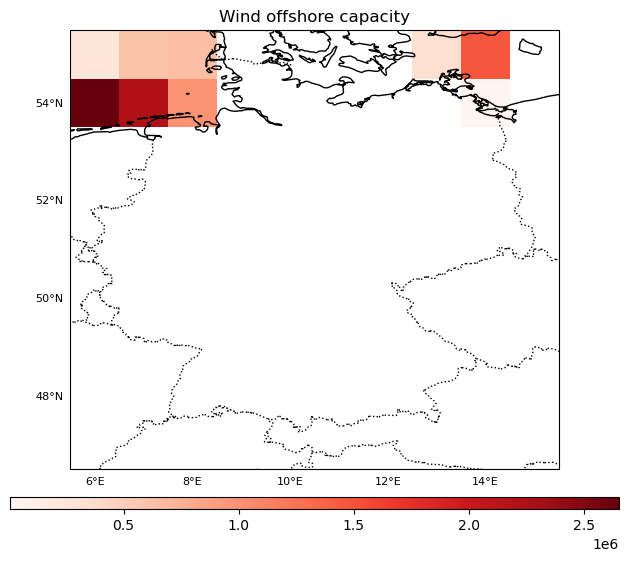

In [15]:
lon_edges = grid.lon.values #- (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values #- (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Wind offshore capacity')

plt.tight_layout()
plt.show()

## Hub Height calculation

In [16]:
# Create a grid
grid_height = grid_func.create_ref_grid('wind_off_hub_height')
# grid_height

### Calculate weighted mean (Based upon the Bruttoleistung)

In [17]:
# Drop data without height values
gdf_2 = gdf.dropna(subset=['Nabenhoehe'])
# gdf_2

In [18]:
grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))
grid_mean_height_weighted

/tmp/ipykernel_3729674/3234131996.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height_weighted = gdf_2.groupby(["lat_idx", "lon_idx"]).apply(lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"]))


lat_idx  lon_idx
7        0          101.015081
         1          103.761859
         2           96.008528
         8          102.000000
8        0           92.025600
         1           91.310000
         2           91.913408
         7           76.700599
         8          102.604423
dtype: float64

In [19]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_mean_height_weighted.items():
    grid_height[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid_height)

In [20]:
# Save grid as raster file
grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')


In [21]:
# Open File
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
# grid

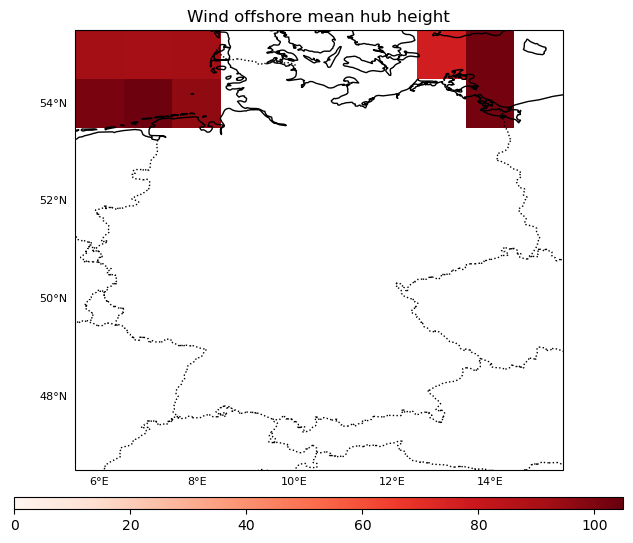

In [22]:
lon_edges = grid.lon.values
lat_edges = grid.lat.values

# Plot the data
min_val = 0 # grid['wind_off_hub_height'].min().values = 76.7
max_val = 105 # grid['wind_off_hub_height'].max().values = 103.76

# from matplotlib.colors import LinearSegmentedColormap

# colors = ['#fcbfa6', '#dd0000', '#6b010e']# ['#ff9999', '#cc0000', '#4d0000']  # light red to dark red
# custom_cmap = LinearSegmentedColormap.from_list("custom_red", colors)

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_off_hub_height'], transform=ccrs.PlateCarree(), cmap='Reds', vmin=min_val, vmax=max_val)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = MultipleLocator(2)
gl.ylocator = MultipleLocator(2)
ax.set_title('Wind offshore mean hub height')

plt.tight_layout()
plt.show()